In [1]:
import sys
# sys.path.append('/home/codecrack/Jnotebook/')
import pandas as pd

### Loading the dataset that included the Metric sccore on each stimulus

In [3]:
metric_data = pd.read_csv('./Metric/MetricFull.csv')

In [4]:
metrics = ["HAAQI", "PEAQ_B", "PEAQ_ADV", "VISQ", "PEMO"]
sub_jective_data = pd.read_csv('df_rating_dataset.csv')
sub_jective_data_full = sub_jective_data.groupby(["Instruments", "Intervals", "rating_stimulus"])["rating_score"].mean().reset_index()
metric_data_formal = pd.concat([sub_jective_data_full.reset_index(drop=True), metric_data[metrics].reset_index(drop=True)], axis=1)
metric_data_formal

,Instruments,Intervals,rating_stimulus,rating_score,HAAQI,PEAQ_B,PEAQ_ADV,VISQ,PEMO
0,cello,C3A#3,32k,15.285714,0.620239,0.11450,0.09800,0.232968,0.161279
1,cello,C3A#3,96k,75.785714,0.879597,0.41325,0.68100,0.775078,0.712069
2,cello,C3A#3,96k_ak_EQ,51.214286,0.735678,0.24325,0.32025,0.695846,0.416898
3,cello,C3A#3,96k_muk_EQ,61.571429,0.682010,0.14725,0.21150,0.804336,0.294279
4,cello,C3A#3,wav,81.857143,1.000000,1.00000,1.00000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...
163,pipeorgan,C4G4,96k_ak_EQ,33.571429,0.214087,0.34525,0.09700,0.883456,0.698549
164,pipeorgan,C4G4,96k_muk_EQ,60.642857,0.484802,0.23475,0.10500,0.872248,0.504603
165,pipeorgan,C4G4,wav,79.714286,1.000000,1.00000,1.00000,1.000000,1.000000
166,pipeorgan,C4G4,wav_ak_EQ,47.714286,0.238881,0.39125,0.09700,0.881960,0.695522


In [5]:
import pandas as pd
from scipy.stats import pearsonr

# Define the metric columns
#metrics = ["HAAQI", "PEAQ_B", "PEAQ_ADV", "VISQ", "PEMO"]


# Split the dataset into two groups based on rating_stimulus
# Function to compute correlations and p-values
def compute_corr_and_p(df):
    results = {}
    for metric in metrics:
        corr, p_val = pearsonr(df[metric], df["rating_score"])
        results[metric] = {"Correlation": corr, "p-value": p_val}
    return pd.DataFrame(results).T

# Compute for both groups
ref_stats = compute_corr_and_p(metric_data_formal)

# Rename columns
ref_stats.columns = ["Corr", "p-value"]
ref_stats

,Corr,p-value
HAAQI,0.607884,2.375147e-18
PEAQ_B,0.576611,2.856366e-16
PEAQ_ADV,0.723288,1.720567e-28
VISQ,0.424936,9.404735e-09
PEMO,0.592948,2.495840e-17


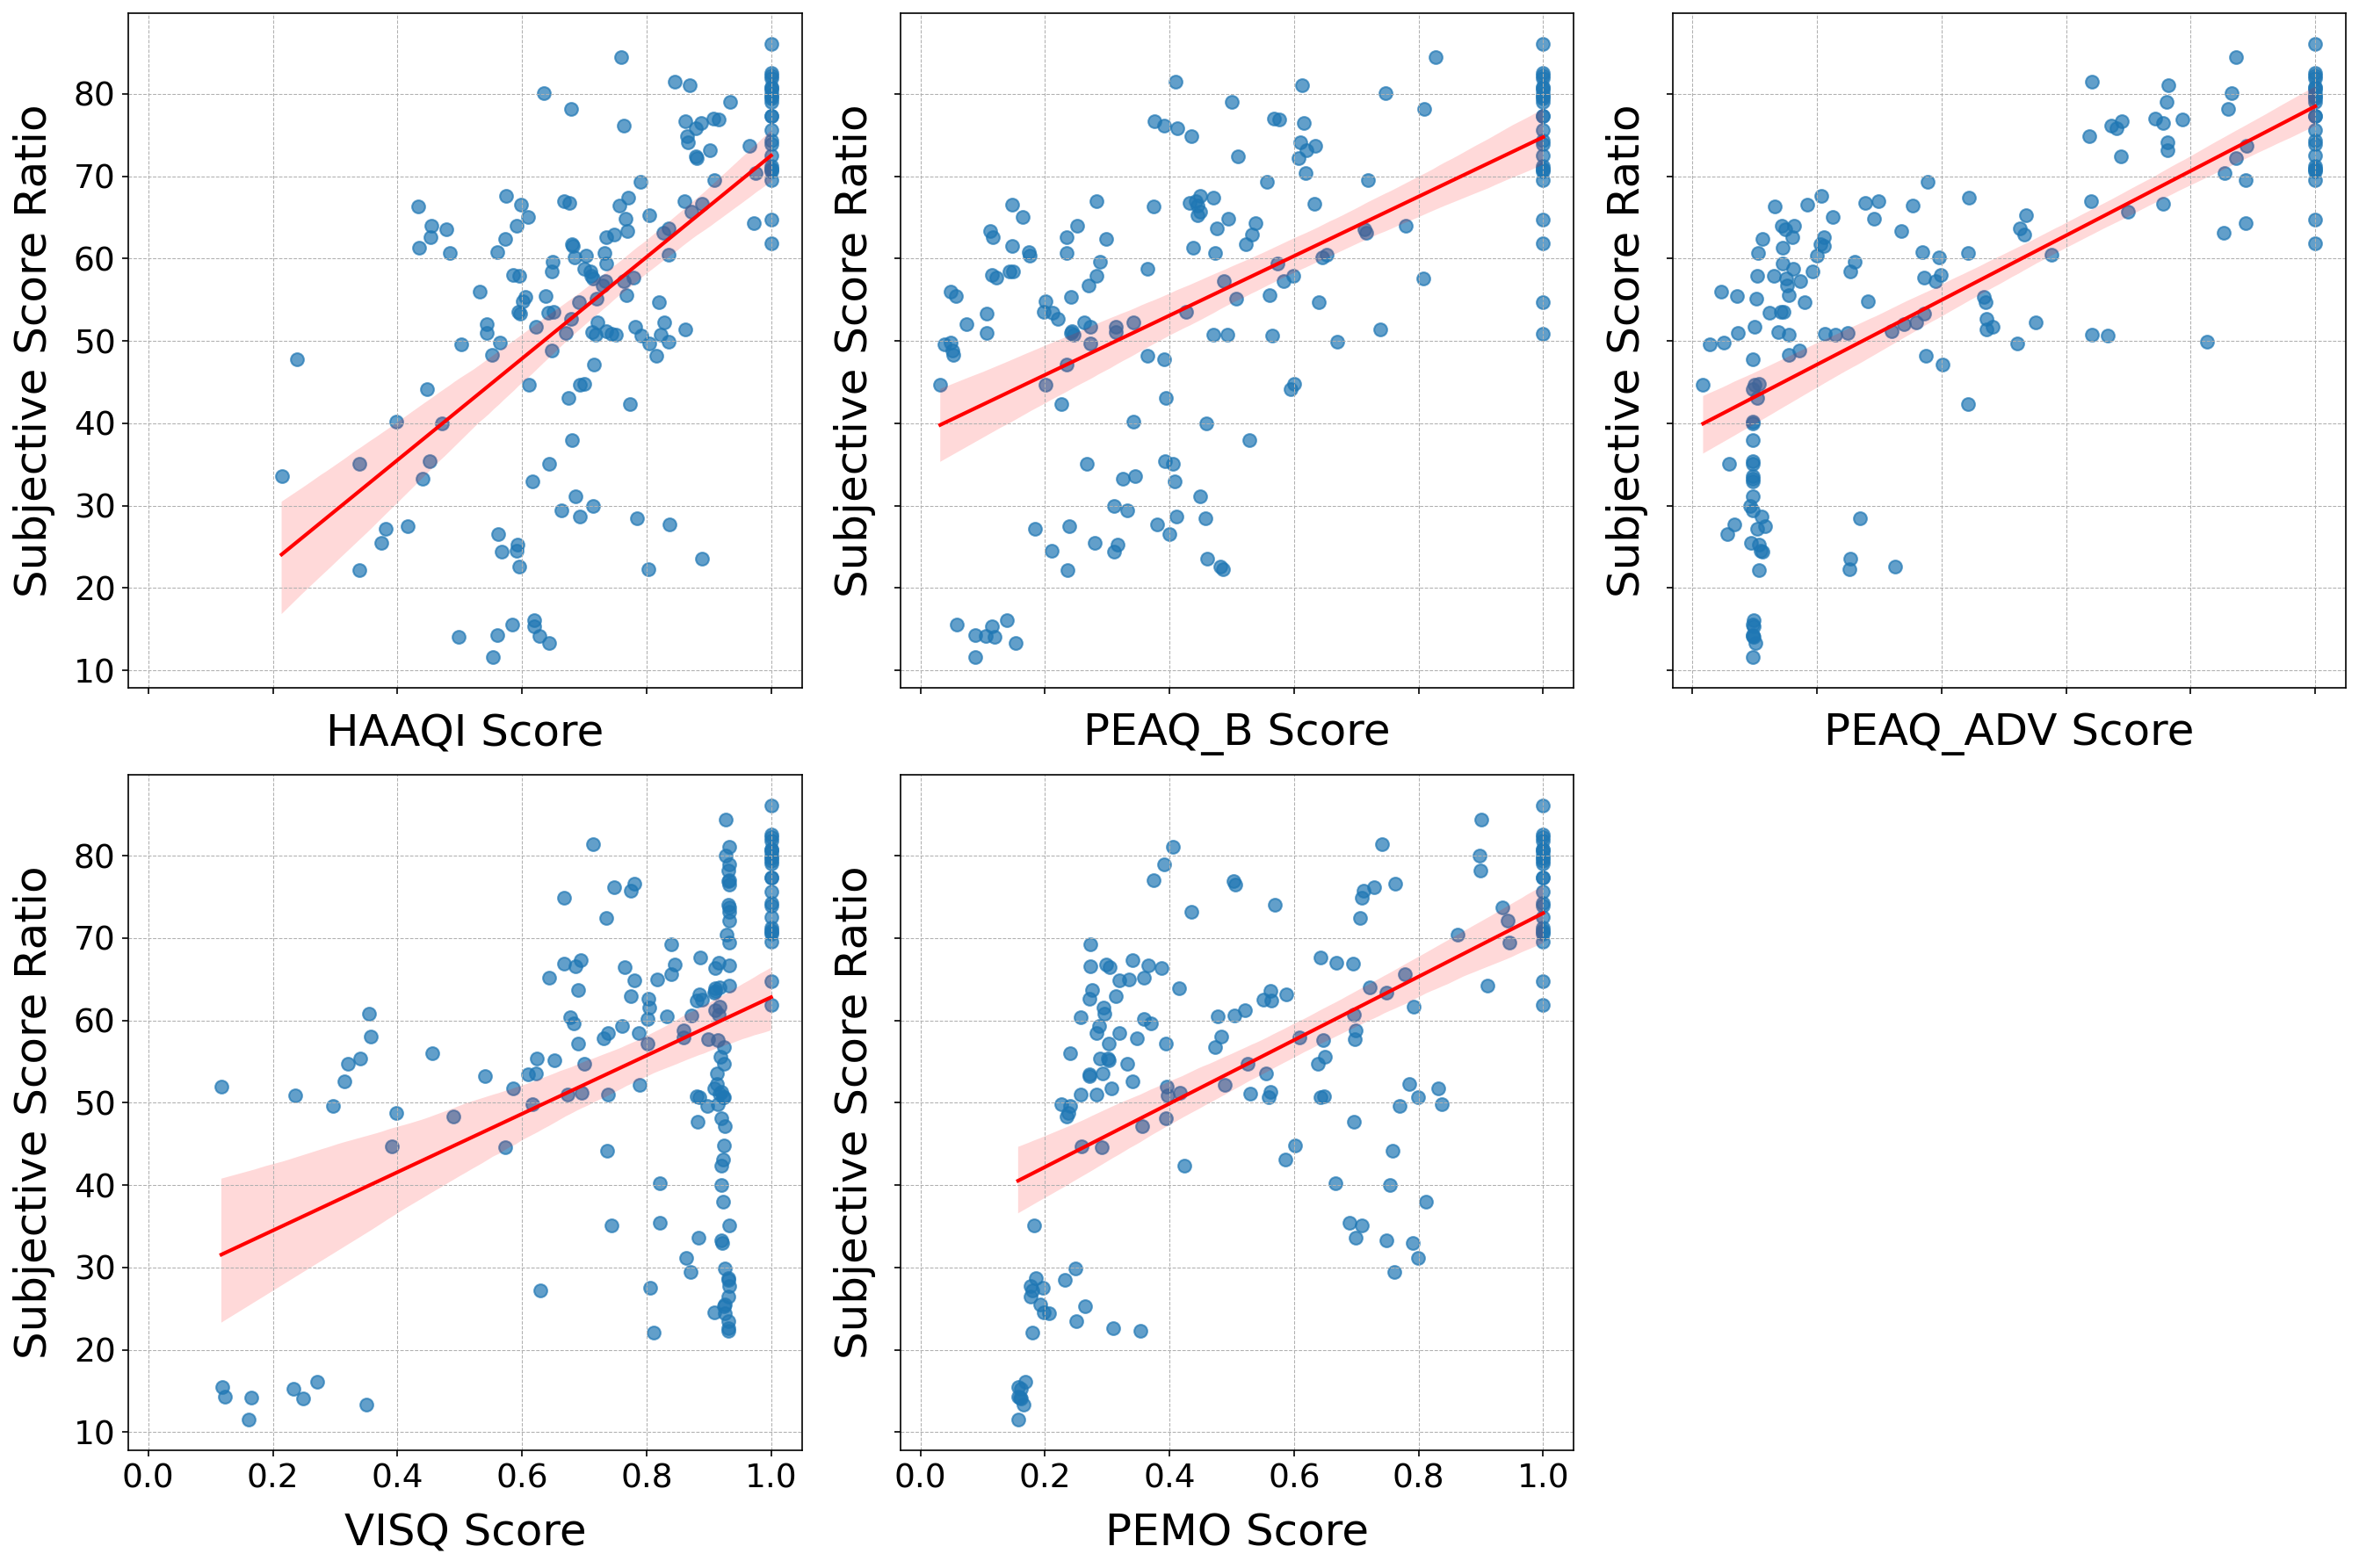

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np
from sklearn.linear_model import LinearRegression

# Define the metric columns to plot
metrics = ["HAAQI", "PEAQ_B", "PEAQ_ADV", "VISQ", "PEMO"]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12),dpi=150,sharex=True, sharey=True)
axes = axes.flatten()

# Loop through each metric and plot
for i, metric in enumerate(metrics):
    x_values = metric_data_formal[metric]
    y_values = metric_data_formal["rating_score"]

    corr, _ = pearsonr(x_values, y_values)
    model = LinearRegression()
    model.fit(x_values.values.reshape(-1, 1), y_values)
    r_squared = model.score(x_values.values.reshape(-1, 1), y_values)

    sns.regplot(
        x=x_values,
        y=y_values,
        scatter_kws={"s": 50, "alpha": 0.7},
        line_kws={"color": "red", "linewidth": 2},
        ax=axes[i],
    )

    # set axis label fonts and tick label size
    axes[i].set_xlabel(f"{metric} Score", fontsize=24, labelpad=10)
    axes[i].set_ylabel("Subjective Score Ratio", fontsize=24, labelpad=10)
    axes[i].tick_params(axis="both", labelsize=18)
    axes[i].grid(True, linestyle="--", linewidth=0.5)

# Remove unused subplot if any
if len(metrics) < len(axes):
    for j in range(len(metrics), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
